Dataset from: https://www.kaggle.com/code/nikolayshivarov2000/hybrid-usic-recommendation-system/notebook


# Content

1. **Importing Datasets and Basic Python Packages**
2. **Data Preprocessing and Visualisation of Item Dataset (music_info)**
   1. Inspecting Dataset
   2. Dropping unnecessary columns
   3. Checking for Missing Values
   4. Checking for Duplicates
   5. Encoding Categorical Features
   6. Normalizing Audio Features
   7. Mood Classification
   8. Feature Correlation
   9. Tag Correlation
   10. Average Emotion Feature by Tag
   11. Correlation Between Top Tags and Music Features
   12. Mood Distribution Per Tag
   13. Mood Normalization
4. **Data Preprocessing and Visualisation of User-Item Dataset (users_history)**
   1. Inspecting Dataset
   2. Distribution of User Playcounts
   3. Check for Missing Values
   4. Checking for Duplicates
   5. Grouping Songs of Each User
   6. Removing Users Who Have Too Few Interactions
   7. Normalization
   8. Verify Matching Track Id Column Between User-Item and Item Dataset
   9. Saving Preprocessed Datasets

## 1. Importing Datasets and Basic Python Packages

In [18]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style="whitegrid")

In [19]:
users_history = pd.read_csv("User Listening History.csv")
music_info  = pd.read_csv("Music Info.csv")

## 2. Data Preprocessing and Visualisation of Item Dataset (music_info)

We start by preprocessing the music_info dataset.

#### 2.1 Inspecting dataset


In [20]:
music_info.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [21]:
music_info.shape

(50683, 21)

In [22]:
music_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

From the output above we learn the count and datatype of each column.

*   **Object cloumns**: track_id, name, artist, spotify_preview_url, spotify_id, tags, genre
*   **Float columns**: danceability, energy, acousticness, instrumentalness, liveness, valence, tempo
*   **Integer columns**: time_signature, mode, key, year, duration_ms



#### 2.2 Dropping unnecesary columns

To start, we chose to drop the **name (track title)** column. This is because the column has very high cardinaliry, where each track has a unique title, which means encoding it would create thousands of non-informative features. Aditionally, we already have a unique identifier in the "track_id" column. Therefore, including it would only increase model complexity without adding predictive value.

We will keep the name column as metadata separately for displaying song recommendations to user after model predicts relevant track IDs.




In [23]:
# Storing name and artist for displaying song recommendations later
music_info_metadata = music_info[['track_id', 'name', 'artist']].copy()

# Saving to CSV to use in recommender model jupyter file
music_info_metadata.to_csv("data/music_info_metadata.csv", index=False)


# Dropping the name column before training the model
music_info = music_info.drop(columns=['name'])

The columns **spotify_preview_url** and **spotify_id** are unique identifiers and external links for each track. However, they do not provide any meaningful information considering we already have a unique identifier for each song (track_id).

In [24]:
music_info = music_info.drop(columns=['spotify_preview_url', 'spotify_id'])

#### 2.3 Checking for null values

From the info of the music dataset above, we can also see that the tag and genre column contain some null values that we need to remove. This can also be seen in the visualization graph below.

<Axes: >

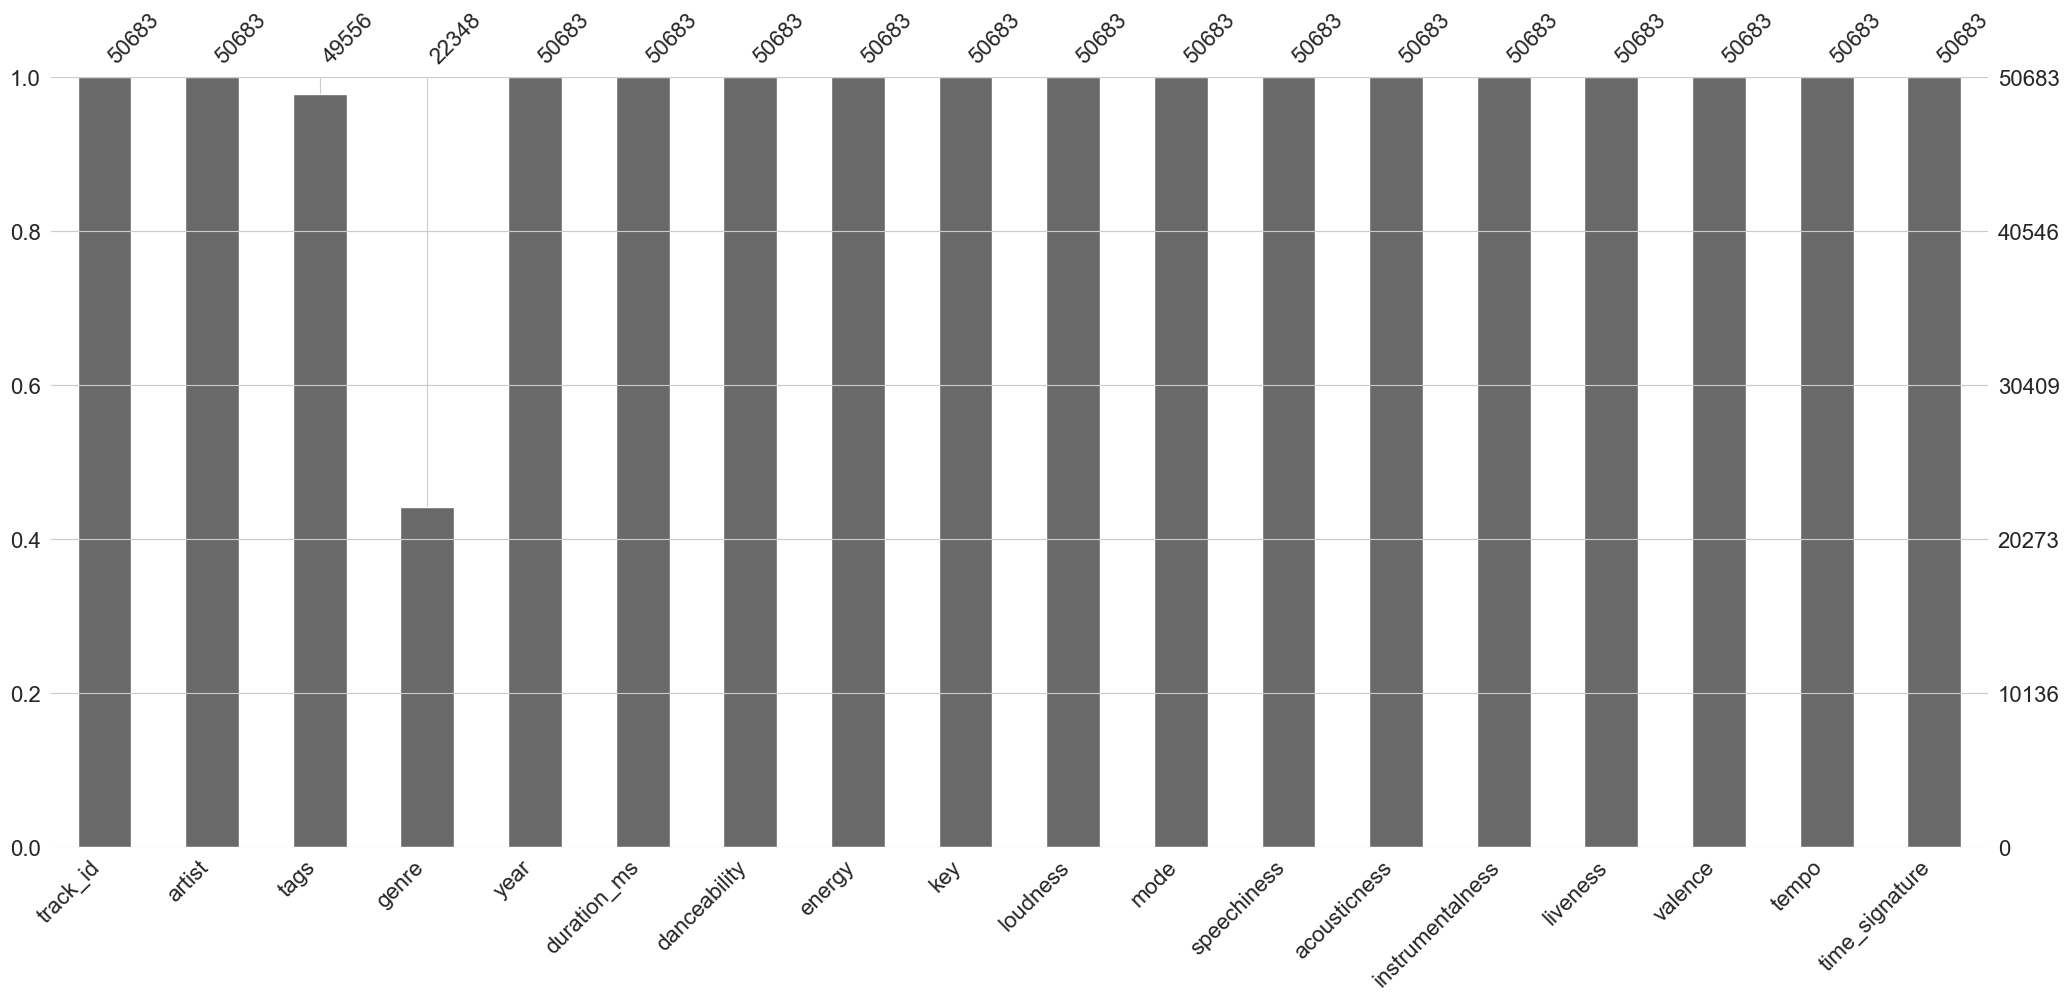

In [25]:
msno.bar(music_info)

In [26]:
# Checking how many values are null
print(music_info.isnull().sum())

track_id                0
artist                  0
tags                 1127
genre               28335
year                    0
duration_ms             0
danceability            0
energy                  0
key                     0
loudness                0
mode                    0
speechiness             0
acousticness            0
instrumentalness        0
liveness                0
valence                 0
tempo                   0
time_signature          0
dtype: int64


We decide to drop the genre column due to the large proportion of missing values. Additionally, genre can be subjective and overlapping, for example pop rock and alternative pop, which can reduce the model's ability to capture meaningful distinctions. Since other columns like artist, album and song features already capture musical characteristics, removing the genre column will simplify the dataset without losing critical information.

In [27]:
# Dropping the genre column
music_info.drop('genre', axis=1, inplace=True)

In [28]:
# Filling missing tags that are NaN values
music_info['tags'] = music_info['tags'].fillna('Unknown')

print(music_info['tags'].isnull().sum())

0


In [29]:
music_info.describe()

,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,50683.000000,5.068300e+04,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000,50683.000000
mean,2004.017323,2.511551e+05,0.493537,0.686486,5.312748,-8.291204,0.631060,0.076023,0.213808,0.225283,0.215425,0.433134,123.507682,3.898151
std,8.860172,1.075860e+05,0.178838,0.251808,3.568078,4.548365,0.482522,0.076007,0.302848,0.337049,0.184697,0.258779,29.621125,0.419670
min,1900.000000,1.439000e+03,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.000000,1.927330e+05,0.364000,0.514000,2.000000,-10.375000,0.000000,0.035200,0.001400,0.000018,0.098400,0.214000,100.683000,4.000000
50%,2006.000000,2.349330e+05,0.497000,0.744000,5.000000,-7.200000,1.000000,0.048200,0.039900,0.005630,0.138000,0.405000,121.989000,4.000000
75%,2009.000000,2.881930e+05,0.621000,0.905000,9.000000,-5.089000,1.000000,0.083500,0.340000,0.441000,0.289000,0.634000,141.639000,4.000000
max,2022.000000,3.816373e+06,0.986000,1.000000,11.000000,3.642000,1.000000,0.954000,0.996000,0.999000,0.999000,0.993000,238.895000,5.000000


#### 2.4 Checking for duplicates

In [30]:
# Counting duplicates
count_duplicates = music_info.duplicated().sum()
print(f"Number of duplicate rows: {count_duplicates}")

Number of duplicate rows: 0


#### 2.5 Encoding categorical features

Since name and genre has been dropped, now only **artist** and **tag** column remain as categorical features.

Each song has multiple tags, so we treat them as multi-hot features. Each unique tag beceomes a separate column and we mark 1 if the song has that tag and 0 otherwise. This allows the model to learn which tag combinations are associated with user preferences.


In [31]:
# Split tags into lists
music_info['tags_list'] = music_info['tags'].apply(lambda x: x.split(', '))

# Multi-hot encoding (using MultiLabelBinarizer for efficiency)
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

# Making encoded tags into dataframe to concat to original data below
tags_encoded = pd.DataFrame(mlb.fit_transform(music_info['tags_list']),
                            columns=[f'tag_{c}' for c in mlb.classes_]) # Setting name for columns
                        
# Inspecting all tag names stored in mlb.classes_
print(mlb.classes_)

['00s' '60s' '70s' '80s' '90s' 'Unknown' 'acoustic' 'alternative'
 'alternative_rock' 'ambient' 'american' 'avant_garde' 'beautiful'
 'black_metal' 'blues' 'blues_rock' 'british' 'britpop' 'chill' 'chillout'
 'classic_rock' 'classical' 'country' 'cover' 'dance' 'dark_ambient'
 'death_metal' 'doom_metal' 'downtempo' 'drum_and_bass' 'electro'
 'electronic' 'emo' 'experimental' 'female_vocalists' 'folk' 'french'
 'funk' 'german' 'gothic' 'gothic_metal' 'grindcore' 'grunge' 'guitar'
 'hard_rock' 'hardcore' 'heavy_metal' 'hip_hop' 'house' 'idm' 'indie'
 'indie_pop' 'indie_rock' 'industrial' 'instrumental' 'j_pop' 'japanese'
 'jazz' 'lounge' 'love' 'male_vocalists' 'mellow' 'melodic_death_metal'
 'metal' 'metalcore' 'new_age' 'new_wave' 'noise' 'nu_metal' 'oldies'
 'piano' 'polish' 'pop' 'pop_rock' 'post_hardcore' 'post_punk' 'post_rock'
 'power_metal' 'progressive_metal' 'progressive_rock' 'psychedelic'
 'psychedelic_rock' 'punk' 'punk_rock' 'rap' 'reggae' 'rnb' 'rock'
 'russian' 'screamo' 

In [32]:
# Drop original tag column and concatenate multi-hot features
music_info = pd.concat([music_info.drop(columns=['tags', 'tags_list']), tags_encoded], axis=1)

# Check
print(music_info.filter(like='tag_').head())

   tag_00s  tag_60s  tag_70s  tag_80s  tag_90s  tag_Unknown  tag_acoustic  \
0        1        0        0        0        0            0             0   
1        0        0        0        0        1            0             0   
2        0        0        0        0        1            0             0   
3        1        0        0        0        0            0             0   
4        0        0        0        0        1            0             0   

   tag_alternative  tag_alternative_rock  tag_ambient  ...  tag_ska  tag_soul  \
0                1                     1            0  ...        0         0   
1                1                     1            0  ...        0         0   
2                1                     1            0  ...        0         0   
3                1                     1            0  ...        0         0   
4                1                     1            0  ...        0         0   

   tag_soundtrack  tag_swedish  tag_symphonic_meta

For the artist column we use label encoding because each track has a single artist, so there is no need to expand into multiple columns like one-hot encoding. Label encoding will assign a unique integer to each artist.

In [33]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

music_info['artist_encoded'] = label_encoder.fit_transform(music_info['artist'].astype(str))

# Dropping the original artist column to avoid duplication
music_info.drop(columns=['artist'], inplace=True)

# Check results
print(music_info[['artist_encoded']].head())


   artist_encoded
0            7209
1            5262
2            5194
3            2672
4            5740


#### 2.6 Normalizing audio features

In [34]:
# Releavnt columns for emotional expression
feature_columns = ['danceability', 'energy', 'loudness', 'speechiness',
           'acousticness', 'instrumentalness', 'liveness',
           'valence', 'tempo', 'mode']

In [35]:
# Before normalization
print(music_info[feature_columns].describe())

       danceability        energy      loudness   speechiness  acousticness  \
count  50683.000000  50683.000000  50683.000000  50683.000000  50683.000000   
mean       0.493537      0.686486     -8.291204      0.076023      0.213808   
std        0.178838      0.251808      4.548365      0.076007      0.302848   
min        0.000000      0.000000    -60.000000      0.000000      0.000000   
25%        0.364000      0.514000    -10.375000      0.035200      0.001400   
50%        0.497000      0.744000     -7.200000      0.048200      0.039900   
75%        0.621000      0.905000     -5.089000      0.083500      0.340000   
max        0.986000      1.000000      3.642000      0.954000      0.996000   

       instrumentalness      liveness       valence         tempo  \
count      50683.000000  50683.000000  50683.000000  50683.000000   
mean           0.225283      0.215425      0.433134    123.507682   
std            0.337049      0.184697      0.258779     29.621125   
min         

In [36]:
# Normalizing the features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

music_info[feature_columns] = scaler.fit_transform(music_info[feature_columns])

In [37]:
# After normalizing
print(music_info[feature_columns].describe())

       danceability        energy      loudness   speechiness  acousticness  \
count  50683.000000  50683.000000  50683.000000  50683.000000  50683.000000   
mean       0.500544      0.686486      0.812495      0.079688      0.214666   
std        0.181377      0.251808      0.071468      0.079672      0.304065   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.369168      0.514000      0.779752      0.036897      0.001406   
50%        0.504057      0.744000      0.829641      0.050524      0.040060   
75%        0.629817      0.905000      0.862811      0.087526      0.341365   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

       instrumentalness      liveness       valence         tempo  \
count      50683.000000  50683.000000  50683.000000  50683.000000   
mean           0.225509      0.215640      0.436187      0.516996   
std            0.337387      0.184881      0.260604      0.123992   
min         

In [38]:
# Turning emotion features (minus duration) into dataframe for visaluzation
emotion_features = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'mode'
]

# Create the emotions-only dataset
df_emotions = music_info[emotion_features]


#### 2.7 Mood Classification

In [39]:

def mood_label(row):
    danceability = row['danceability']
    energy = row['energy']
    loudness = row['loudness']
    acousticness = row['acousticness']
    instrumentalness = row['instrumentalness']
    liveness = row['liveness']
    valence = row['valence']
    mode = row['mode']
    tempo = row['tempo']
    speechiness = row['speechiness']

    # {Amusement, happiness, loce, glad, pleased...}
    if valence >= 0.45 and energy >= 0.7:
        return 'Q1'
    # {Panic, anger, despair, anxiety, annoyed, distressed...}
    elif energy >= 0.7 and valence < 0.45:
        return 'Q2'
    # {Sadness, threatened, worried, bored, tired...}
    elif valence < 0.45 and energy < 0.7:
        return 'Q3'
    # {Pride, relief, calm, satisfied, relaxed...}
    elif energy < 0.7 and valence >= 0.45:
        return 'Q4'
    
    else:
        return 'Neutral/Other'

# Adding mood column to dataframe for visualization
df_emotions['mood'] = df_emotions.apply(mood_label, axis=1)

# Adding mood column to music_info for further preprocessing
music_info['mood'] = music_info.apply(mood_label, axis = 1)

# ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
#  'instrumentalness', 'liveness', 'valence', 'tempo', 'mode']

C:\Users\krist\AppData\Local\Temp\ipykernel_1444\163390411.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_emotions['mood'] = df_emotions.apply(mood_label, axis=1)


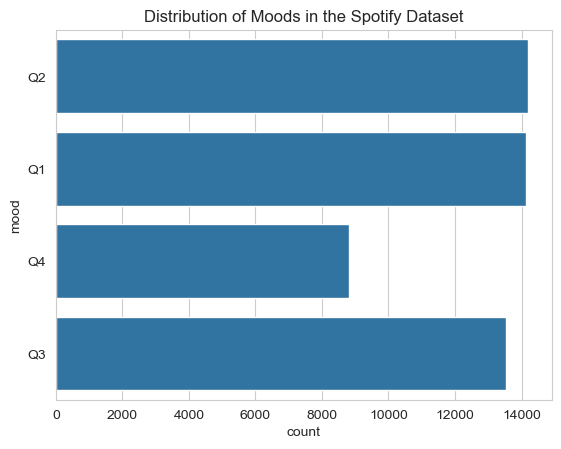

Mood distribution:
mood
Q2    14203
Q1    14134
Q3    13547
Q4     8799
Name: count, dtype: int64


In [40]:
# Mood distribution
sns.countplot(y='mood', data=df_emotions)
plt.title('Distribution of Moods in the Spotify Dataset')
plt.show()

print("Mood distribution:")
print(df_emotions['mood'].value_counts())


#### 2.8 Feature Correlation

In [41]:
feature_corr = music_info[feature_columns].corr()


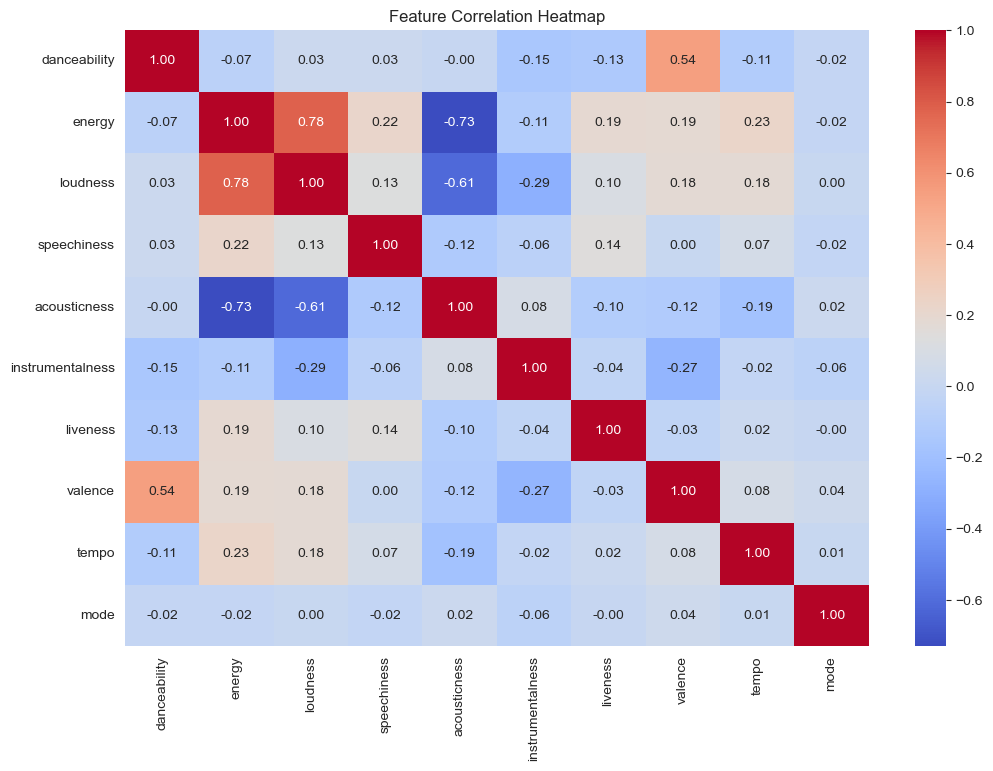

In [42]:
plt.figure(figsize=(12, 8))
sns.heatmap(feature_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

#### 2.9 Tag Correlation

In [43]:
# Select only multi-hot tag columns
tag_cols = music_info.filter(like='tag_')

# Sum each tag column to get total occurrences
tag_counts = tag_cols.sum().sort_values(ascending=False)

# Get top 15 tags (with 'tag_' prefix)
top_tags = tag_counts.head(15).index
top_tags = [t.replace('tag_', '') for t in top_tags]

print(top_tags)


['rock', 'indie', 'electronic', 'alternative', 'pop', 'female_vocalists', 'alternative_rock', 'indie_rock', 'metal', 'classic_rock', 'singer_songwriter', 'experimental', 'chillout', 'ambient', 'folk']


In [44]:
# Add 'tag_' prefix back to match column names
top_tag_cols = music_info[['tag_' + t for t in top_tags]]

# Sum each column to get counts
top_tag_counts = top_tag_cols.sum().sort_values(ascending=False)

print(top_tag_counts)


tag_rock                 10684
tag_indie                 7287
tag_electronic            6594
tag_alternative           6274
tag_pop                   4651
tag_female_vocalists      4517
tag_alternative_rock      4137
tag_indie_rock            3801
tag_metal                 3181
tag_classic_rock          2779
tag_singer_songwriter     2747
tag_experimental          2678
tag_chillout              2655
tag_ambient               2561
tag_folk                  2530
dtype: int64


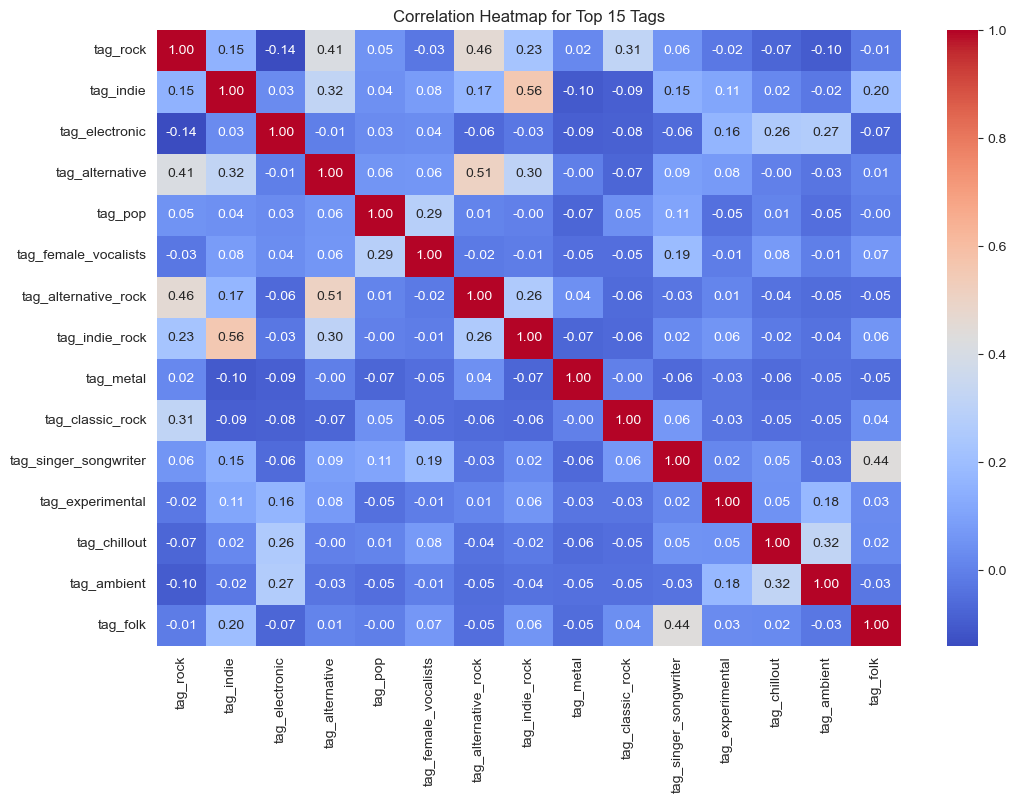

In [45]:
# Compute correlation
tag_correlation = top_tag_cols.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tag_correlation, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap for Top 15 Tags")
plt.show()

#### 2.10 Average Emotion Feature by Tag

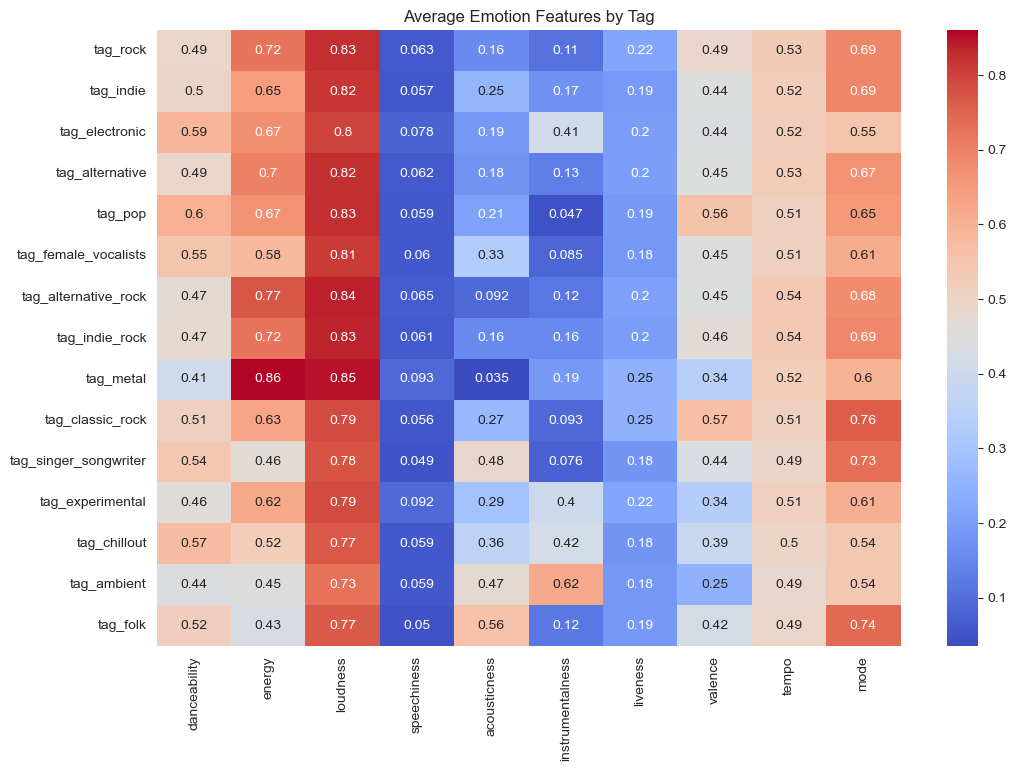

In [46]:
# Compute mean emotion features per tag
valid_top_tags = [f'tag_{t}' for t in top_tags if f'tag_{t}' in music_info.columns]

tag_emotion_means = pd.DataFrame(index=valid_top_tags, columns=feature_columns)

for tag in valid_top_tags:
    tag_emotion_means.loc[tag] = df_emotions[music_info[tag] == 1][feature_columns].mean()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tag_emotion_means.astype(float), cmap='coolwarm', annot=True)
plt.title("Average Emotion Features by Tag")
plt.show()


#### 2.11 Correlation Between Top Tags and Music Features

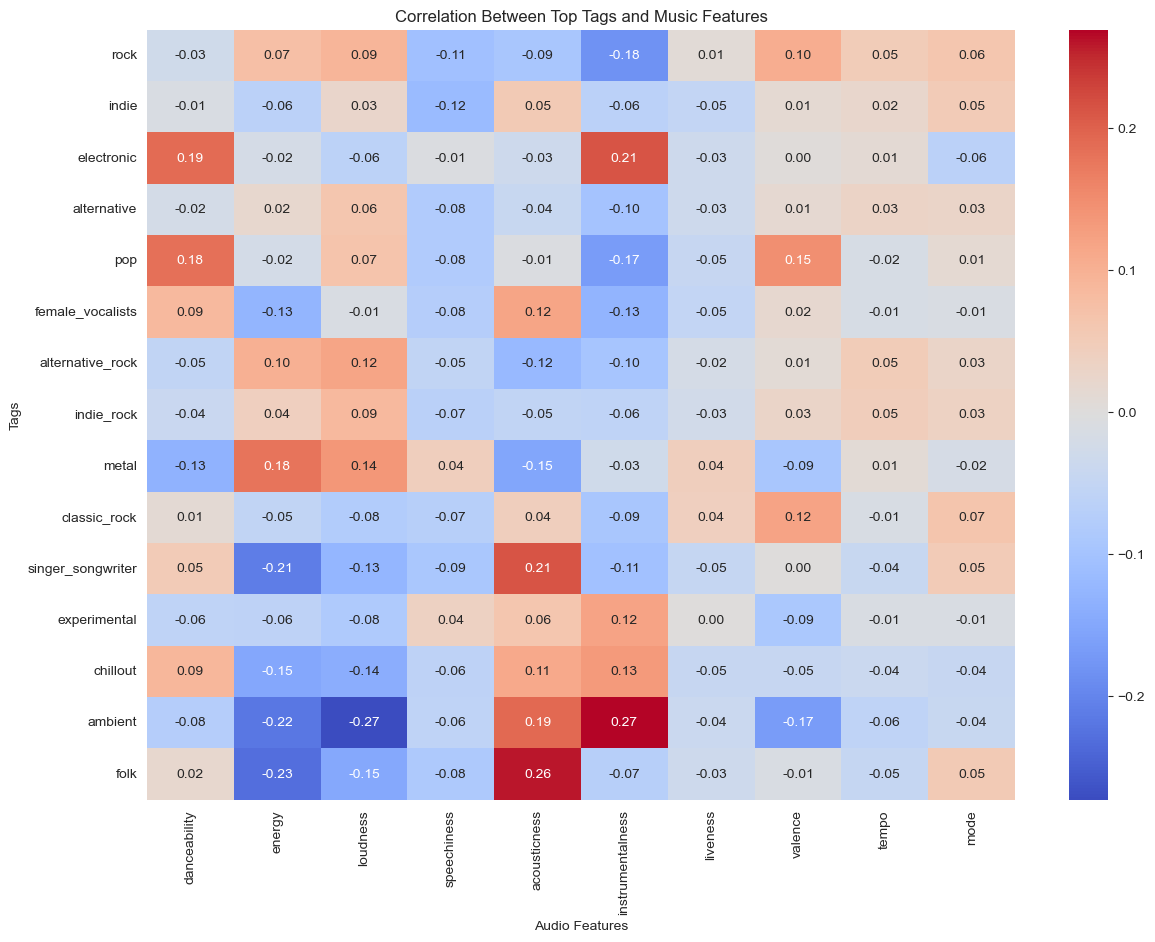

In [47]:
# Select only top tag columns (multi-hot encoded)
top_tags_cols = music_info[valid_top_tags]

# Select numeric feature columns
feature_cols = music_info[feature_columns]

# Combine top tag dummy columns + numeric features
combined_df = pd.concat([top_tags_cols, feature_cols], axis=1)

# Compute correlation for tag vs features only
tag_feature_corr = combined_df.corr().loc[valid_top_tags, feature_columns]

# Remove 'tag_' prefix from row labels for plotting
tag_labels = tag_feature_corr.index.str.replace('tag_', '', regex=False)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(tag_feature_corr, annot=True, cmap='coolwarm', fmt=".2f",
            yticklabels=tag_labels)
plt.title("Correlation Between Top Tags and Music Features")
plt.xlabel("Audio Features")
plt.ylabel("Tags")
plt.show()


#### 2.12 Mood Distribution Per Tag

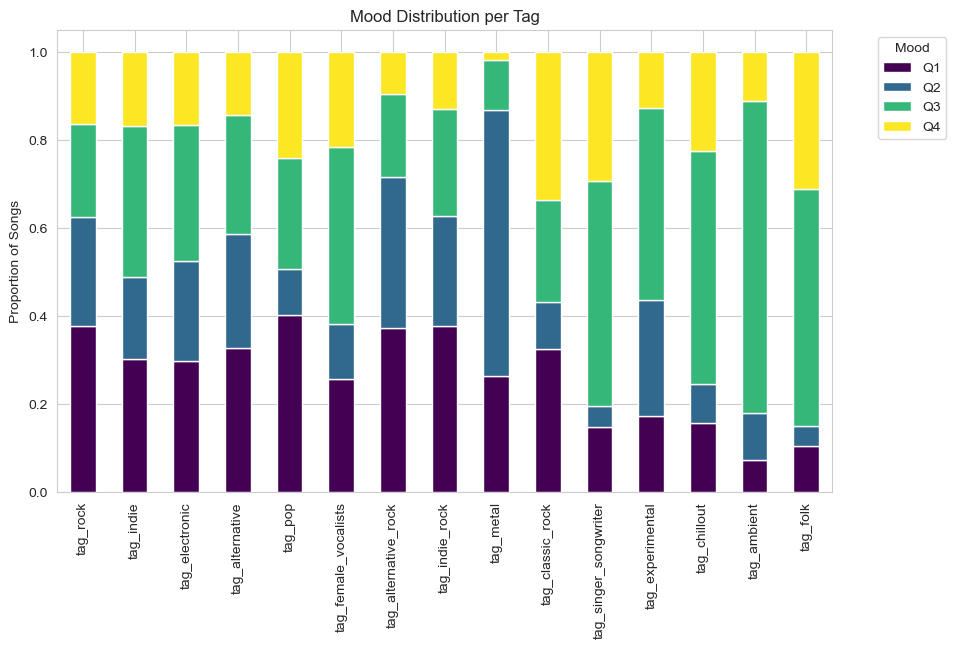

In [48]:
mood_counts = pd.DataFrame(0.0, index=valid_top_tags, columns=df_emotions['mood'].unique(), dtype=float)

for tag in valid_top_tags:
    counts = df_emotions[music_info[tag] == 1]['mood'].value_counts()
    if not counts.empty:
        mood_counts.loc[tag, counts.index] = counts.values

# Normalize to get proportions (relative to all moods)
mood_props = mood_counts.div(mood_counts.sum(axis=1), axis=0)

# Exclude 'Neutral/Other' from the figure and re-normalize across remaining moods
plot_moods = [m for m in mood_props.columns if m != 'Neutral/Other']
mood_props_no_neutral = mood_props[plot_moods].copy()
# Avoid division by zero when a row has all zeros after dropping neutral
row_sums = mood_props_no_neutral.sum(axis=1).replace(0, 1)
mood_props_no_neutral = mood_props_no_neutral.div(row_sums, axis=0)

# Enforce desired mood ordering if present
desired_order = ['Q1', 'Q2', 'Q3', 'Q4']
available = [m for m in desired_order if m in mood_props_no_neutral.columns]
others = [m for m in mood_props_no_neutral.columns if m not in available]
final_cols = available + others
mood_props_no_neutral = mood_props_no_neutral[final_cols]

# Plot stacked bar chart without Neutral/Other
mood_props_no_neutral.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.ylabel("Proportion of Songs")
plt.title("Mood Distribution per Tag")
plt.legend(title='Mood', bbox_to_anchor=(1.05, 1))
plt.show()


#### 2.13 Mood Normalization

In [49]:
# Convering the mood column to a list  which is required by MultiLabelBinarizer, same as tag encoding
music_info['mood_list'] = music_info['mood'].fillna('').apply(lambda x: [x] if x else [])

# Multi-hot encoded moods
mlb = MultiLabelBinarizer()
mood_encoded = pd.DataFrame(mlb.fit_transform(music_info['mood_list']),
                            columns=[f'mood_{c}' for c in mlb.classes_])

# Drop original mood column and the temporary mood_list, adding the encoded mood
music_info = pd.concat([music_info.drop(columns=['mood', 'mood_list']), mood_encoded], axis=1)

# Checking result
print(music_info.filter(like='mood_').head())

   mood_Q1  mood_Q2  mood_Q3  mood_Q4
0        0        1        0        0
1        1        0        0        0
2        1        0        0        0
3        0        0        0        1
4        0        0        1        0


## 3. Data Preprocessing and Visualisation of User-Item Dataset (users_history)

#### 3.1 Inspecting dataset 

In [50]:
users_history.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [51]:
users_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   track_id   object
 1   user_id    object
 2   playcount  int64 
dtypes: int64(1), object(2)
memory usage: 222.3+ MB


In [52]:
users_history.describe()

,playcount
count,9.711301e+06
mean,2.630946e+00
std,5.706324e+00
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,2.000000e+00
max,2.948000e+03


In [53]:
row_count = users_history.shape[0]
print(f"Number of rows in the dataset: {row_count}")

Number of rows in the dataset: 9711301


#### 3.2 Distribution of User Playcounts

In [54]:
# Sum playcounts for each user
user_total_playcounts = users_history.groupby('user_id')['playcount'].sum()


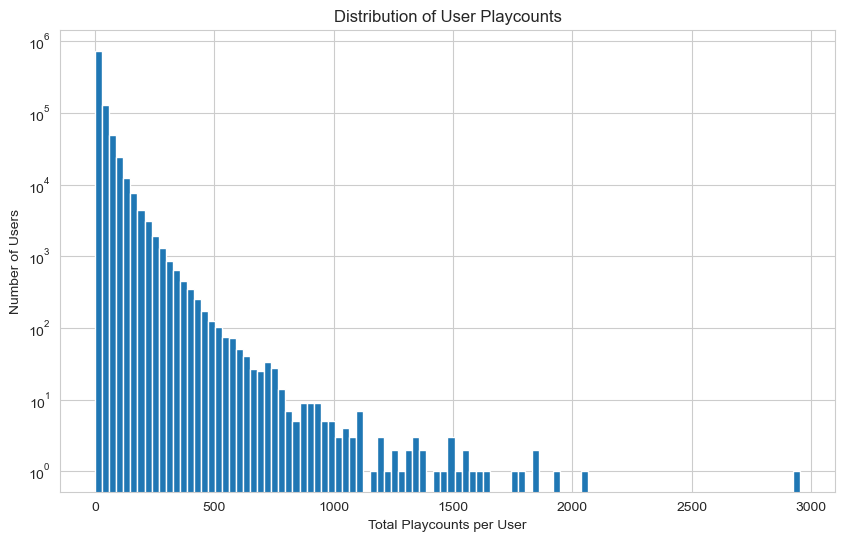

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(user_total_playcounts, bins=100,log = True)
plt.xlabel("Total Playcounts per User")
plt.ylabel("Number of Users")
plt.title("Distribution of User Playcounts")
plt.show()


From the visualization above we can see there are some outliers with 2000+ playcounts. To prevent this from becoming noise in the recommender, we drop all users with playcounts above 2000.

In [56]:
outliers = users_history[users_history['playcount'] > 2000].index
users_history = users_history.drop(outliers)

#### 3.3 Check for missing values

<Axes: >

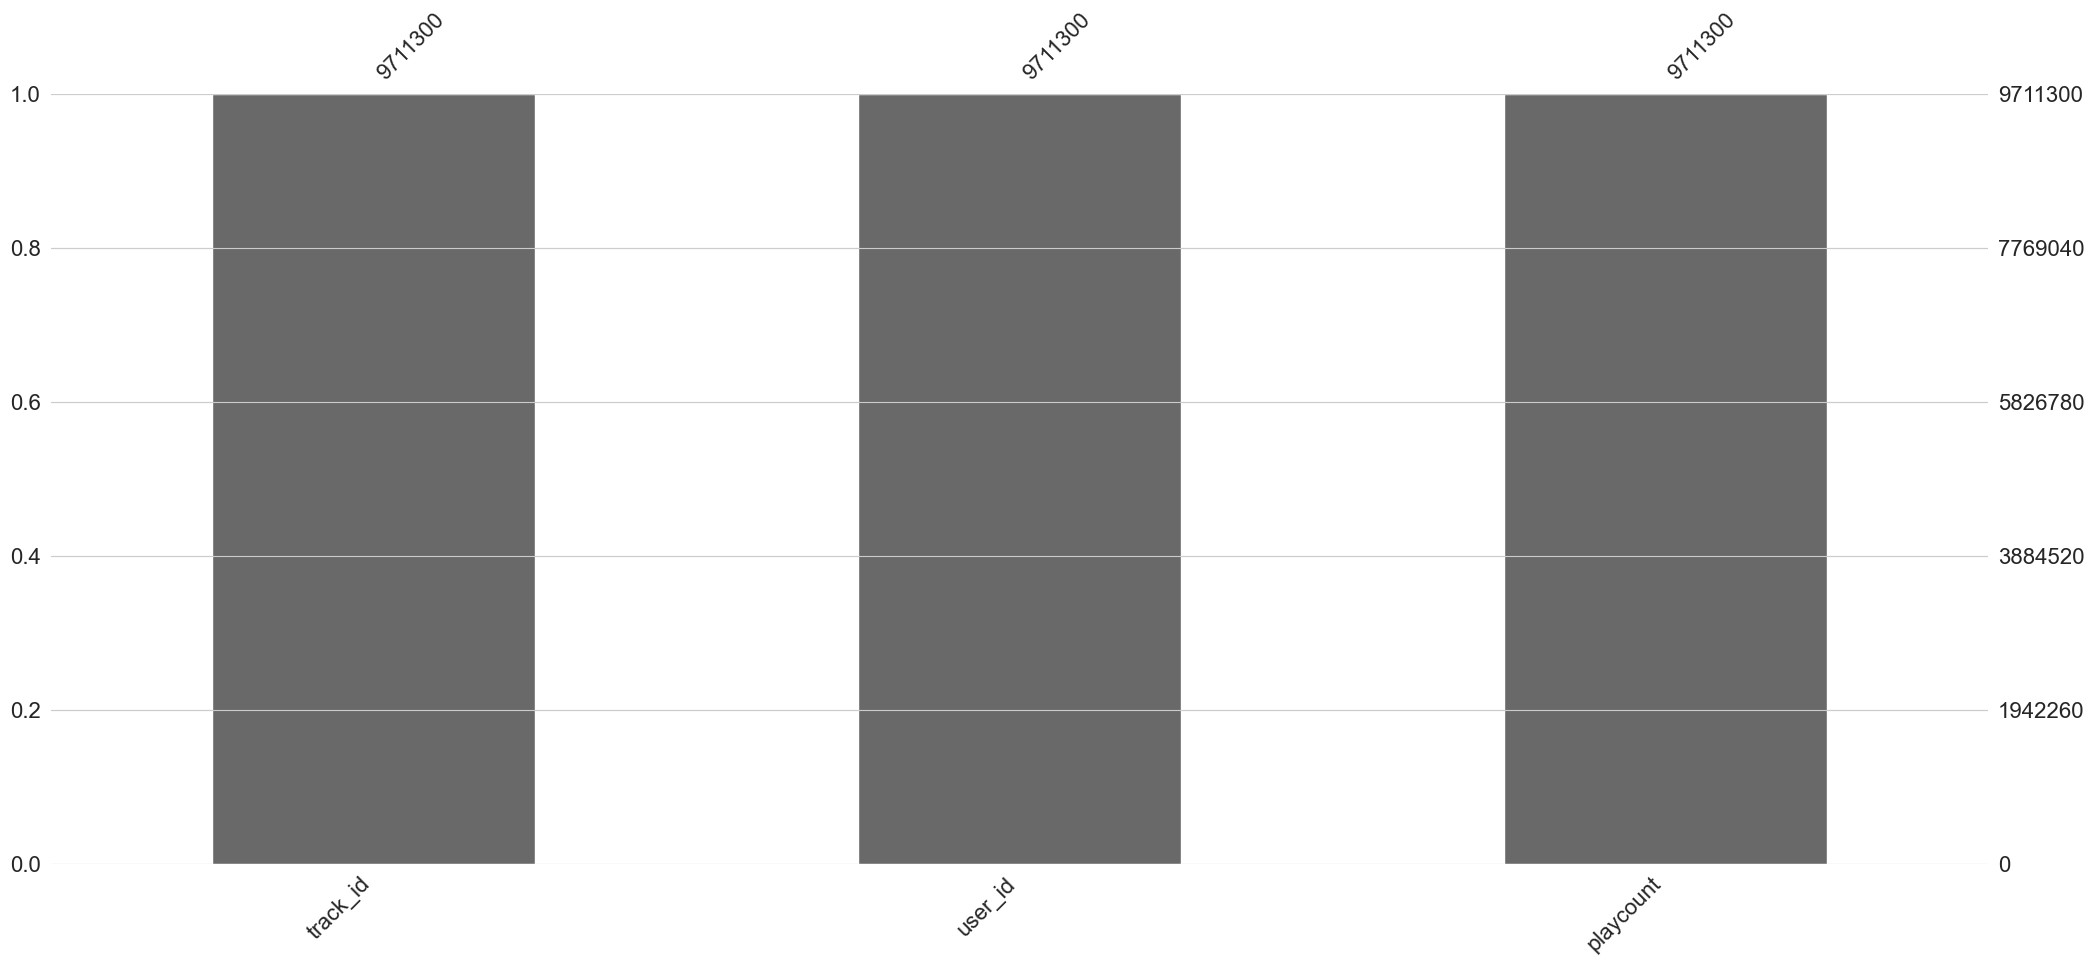

In [57]:
msno.bar(users_history)

In [58]:
# Checking how many values are null
print(users_history.isnull().sum())

track_id     0
user_id      0
playcount    0
dtype: int64


#### 3.4 Checking for duplicates

In [59]:
# Counting duplicates
count_duplicates = users_history.duplicated().sum()
print(f"Number of duplicate rows: {count_duplicates}")

Number of duplicate rows: 0


There are no duplicates, so we do not have to remove any.

#### 3.5 Grouping songs of each user

In [60]:
# Group songs of each user
# Inspired by: https://www.kaggle.com/code/nikolayshivarov2000/hybrid-usic-recommendation-system/notebook
user_song_list = users_history.groupby('user_id', observed=True)[['track_id', 'playcount']].apply(lambda x: list(zip(x['track_id'], x['playcount']))).to_dict()

#### 3.6 Removing users who have too few interactions

In [61]:
# Inspired by: https://www.kaggle.com/code/nikolayshivarov2000/hybrid-usic-recommendation-system/notebook
user_song_list = {user: songs for user, songs in user_song_list.items() if len(songs) > 50}

In [62]:
dict(list(user_song_list.items())[:3])

{'0003a64f7a69e5b87a80b09c3772227185c235c7': [('TRRCWXH128F42B917C', 1),
  ('TRMHZLT12903CEA646', 1),
  ('TROVIQH128F42B91A1', 1),
  ('TRDNHAW128F429DB9A', 1),
  ('TRBVSQT128F427A82F', 1),
  ('TRAFUNV128F92CFEB2', 2),
  ('TRRXFHO128EF3550BC', 1),
  ('TRKQLRS128F4230F04', 1),
  ('TRBVNWT128F93173BA', 1),
  ('TRYYDLF128F423BB17', 1),
  ('TRUWRWK128F92E16B6', 1),
  ('TRMPTXE128F9303E92', 1),
  ('TRNGKOQ128E0780DAC', 1),
  ('TRVKPXM128F4284E60', 1),
  ('TRHTYWL128F429EFD8', 1),
  ('TRBROBA128F9321BC2', 3),
  ('TRFNDHN128F426BE40', 1),
  ('TRAVRKY128F429EA68', 1),
  ('TRILTQH128F93264C4', 1),
  ('TRUTKSF128F147B0E2', 1),
  ('TRBXLFU128F427A494', 1),
  ('TRRUZLF128F42396D0', 1),
  ('TRBMCGS128F92D2C27', 5),
  ('TROBYUK128F9335CA7', 1),
  ('TRKRADU128F92E17F6', 1),
  ('TRJGWMZ128F149F0BD', 1),
  ('TRGVKBK128F429EA2D', 1),
  ('TRIFCFC128F4230F13', 1),
  ('TRJLVOB128F931EB19', 1),
  ('TRJDWKM128E07817F1', 1),
  ('TRNPEXS128F1460294', 5),
  ('TRCYSEC128F428B5E8', 1),
  ('TRTBNOP12903CDB267', 6),

In [63]:
len(user_song_list)

22733

In [64]:
# Removing the data in the original user history dataset
# that have listened to less than 50 songs
users_history = users_history[users_history['user_id'].isin(user_song_list.keys())]

In [65]:
users_history.shape

(1755022, 3)

#### 3.7 Normalization

To ensure all remaining users contribute equally, we scale each user's playcount between 0 and 1 by min-max normalization. To avoid creating null values, we check if a user has all identical values (for example all playcount for that user are the same) before applying normalization.

In [66]:
# Normalize playcount per user safely
def normalize(x):
    if x.max() == x.min():
        return 0 
    else:
        return (x - x.min()) / (x.max() - x.min())

users_history['playcount'] = users_history.groupby('user_id')['playcount'].transform(normalize)


#### 3.8 Verify matching track id column between user-item and item dataset

As a final step we will verify that the track_id column in the music_info dataset matches the ones in the users_history.

In [67]:
common_ids = set(users_history['track_id']).intersection(set(music_info['track_id']))

print(f"Number of overlapping track_ids: {len(common_ids)}")
print(f"% of users_history track_ids in music_info: {len(common_ids)/len(users_history['track_id'].unique()):.2%}")


Number of overlapping track_ids: 26592
% of users_history track_ids in music_info: 100.00%


#### 3.9 Saving preprocessed datasets

In [68]:
music_info.to_csv('data/music_info_cleaned.csv', index=False)
users_history.to_csv('data/users_history_cleaned.csv', index = False)